In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from datetime import datetime
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import mean_shift, estimate_bandwidth
from sklearn.metrics import silhouette_score



In [2]:
costumer = pd.read_csv("customer_info.csv")
costumer

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


In [3]:
costumer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  object 
 2   customer_gender                          33038 non-null  object 
 3   customer_birthdate                       32873 non-null  object 
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377

In [4]:
costumer.describe()

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
count,33038.000000,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,33038.000000,...,32047.000000,32708.00000,32377.000000,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000
mean,19974.265785,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,464.352776,...,608.781228,820.34646,373.900917,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549
std,11538.538632,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,275.767976,...,497.068874,608.31732,460.782042,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581
min,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989
25%,9985.250000,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,241.000000,...,171.000000,362.00000,125.000000,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732
50%,19951.500000,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,421.000000,...,511.000000,686.00000,223.000000,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689
75%,29964.750000,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,640.000000,...,923.000000,1120.00000,374.000000,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608
max,40000.000000,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,2180.000000,...,3172.000000,3482.00000,3936.000000,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697


In [5]:
costumer.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [6]:
costumer.duplicated().sum()

np.int64(0)

In [7]:
# Feature Engineering: Create time-based features using current date,
# so we can use age instead of birthdate,seniority instead of year_of_first_transaction

current_year = datetime.now().year

# Convert birthdate to age
costumer['age'] = current_year - pd.to_datetime(costumer['customer_birthdate']).dt.year

# Convert first transaction year to seniority (years as customer)
costumer['years_as_customer'] = current_year - costumer['year_first_transaction']

C:\Users\anacm\AppData\Local\Temp\ipykernel_7244\3531030275.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  costumer['age'] = current_year - pd.to_datetime(costumer['customer_birthdate']).dt.year


In [8]:
# Initialize the encoder
le = LabelEncoder()

# Example for Gender (converts 'Male'/'Female' to 0/1)
# You should do this BEFORE the MICE imputation if you want it to help
costumer['customer_gender'] = le.fit_transform(costumer['customer_gender'])

# Create a binary flag for loyalty card (1 if they have it, 0 if it's missing)
costumer['has_loyalty_card'] = costumer['loyalty_card_number'].notnull().astype(int)

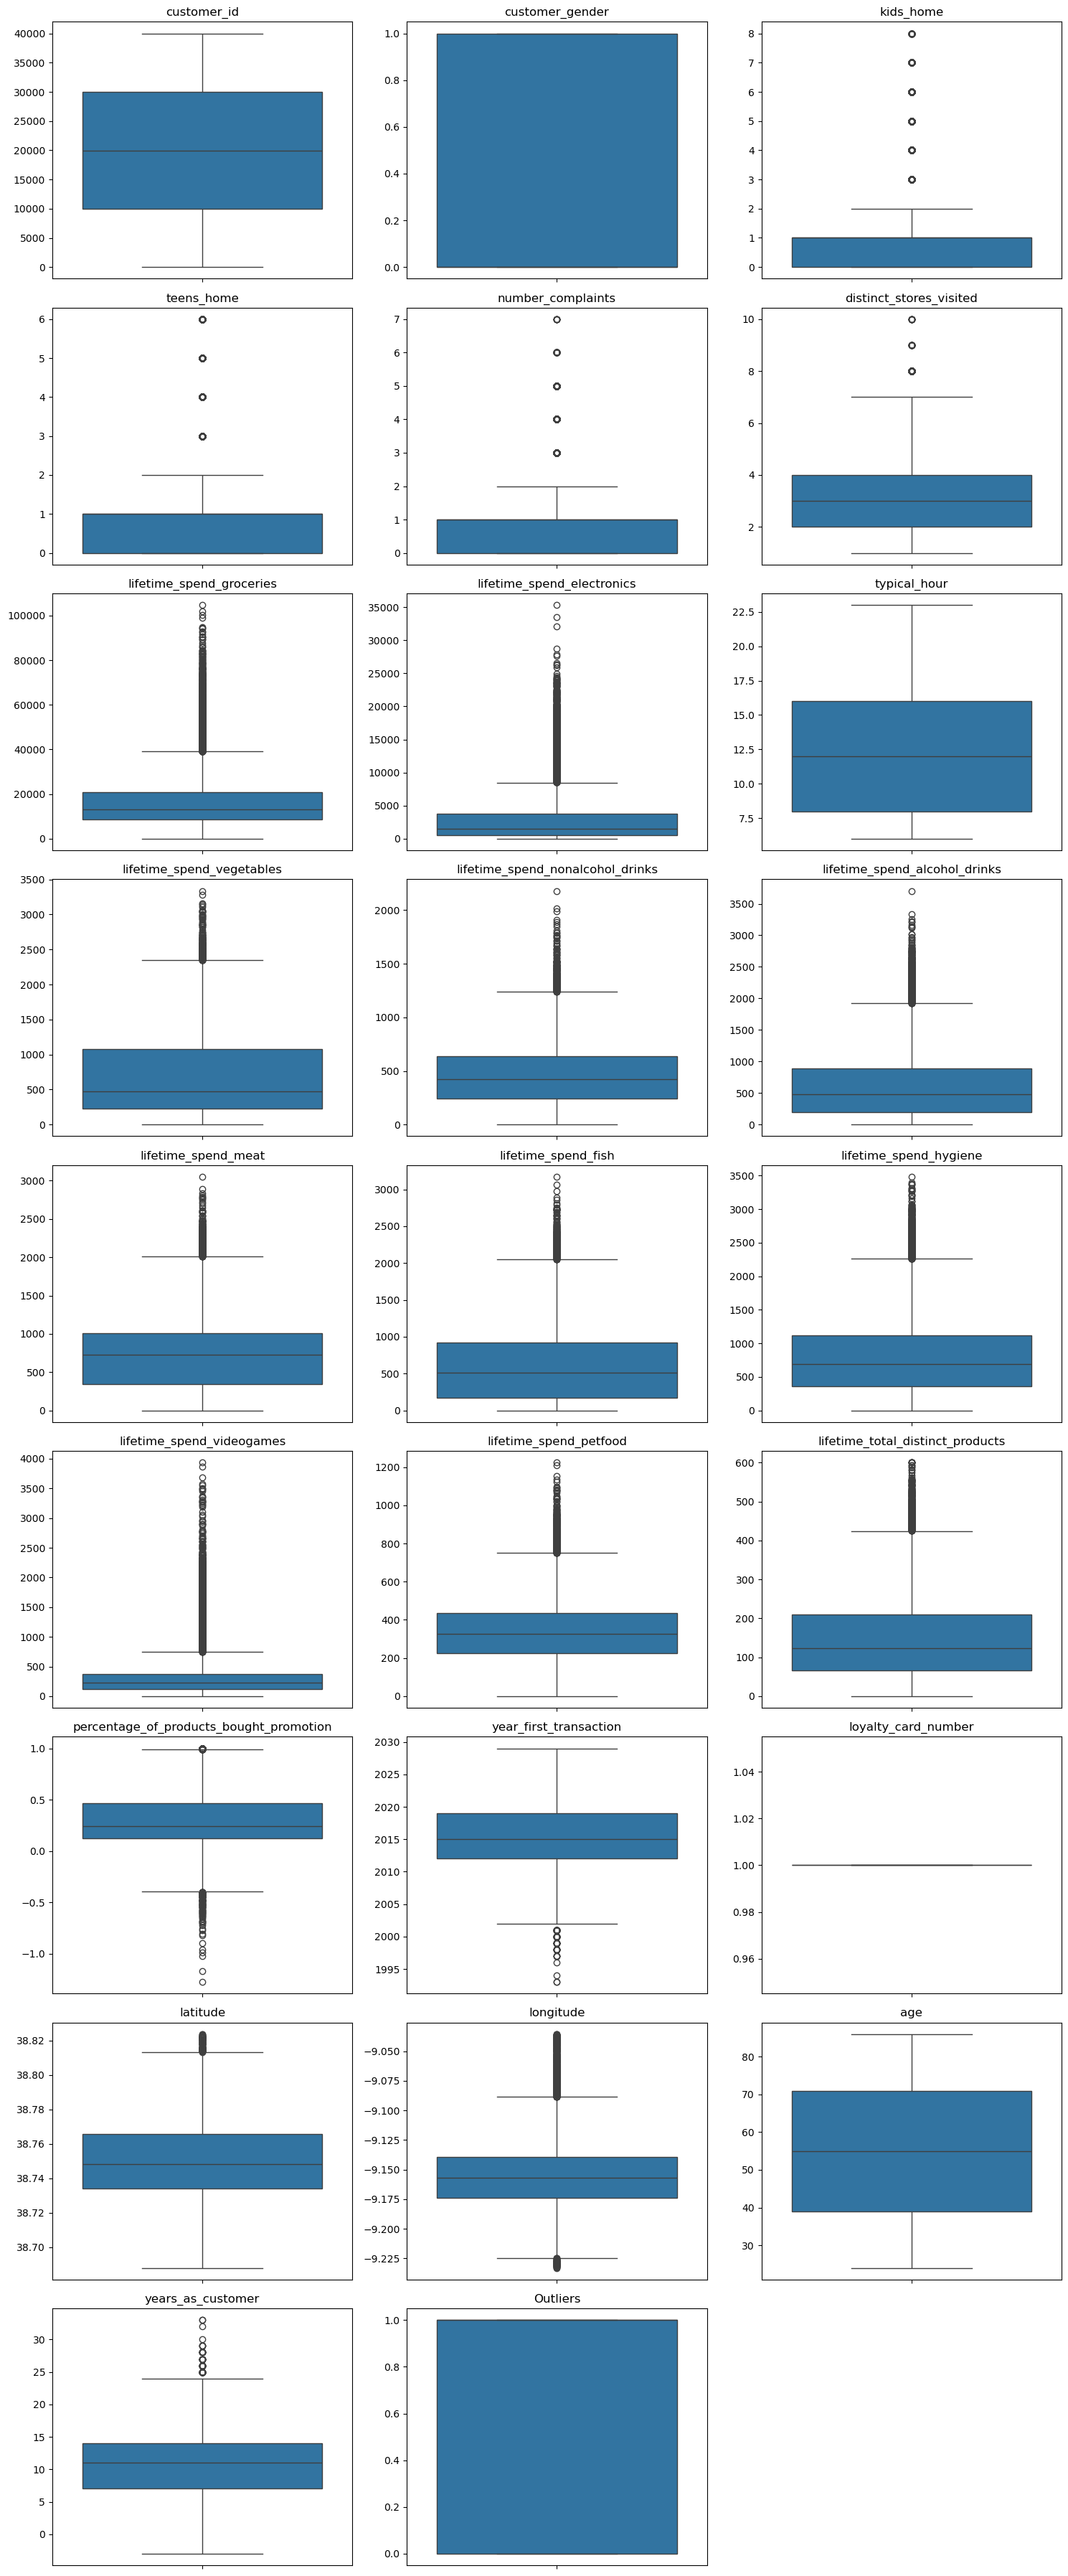

In [9]:
num_cols = costumer.select_dtypes(include=['number']).columns
n_rows = math.ceil(len(num_cols) / 3)


fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.title("Outliers")
plt.show()

In [10]:
for col in num_cols:
    Q1 = costumer[col].quantile(0.25)
    Q3 = costumer[col].quantile(0.75)
    IQR = Q3 - Q1
    

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Capping
    costumer[col] = np.where(costumer[col] > upper, upper,
              np.where(costumer[col] < lower, lower, costumer[col]))

print("Outliers treated in every numeric columns!")

Outliers treated in every numeric columns!


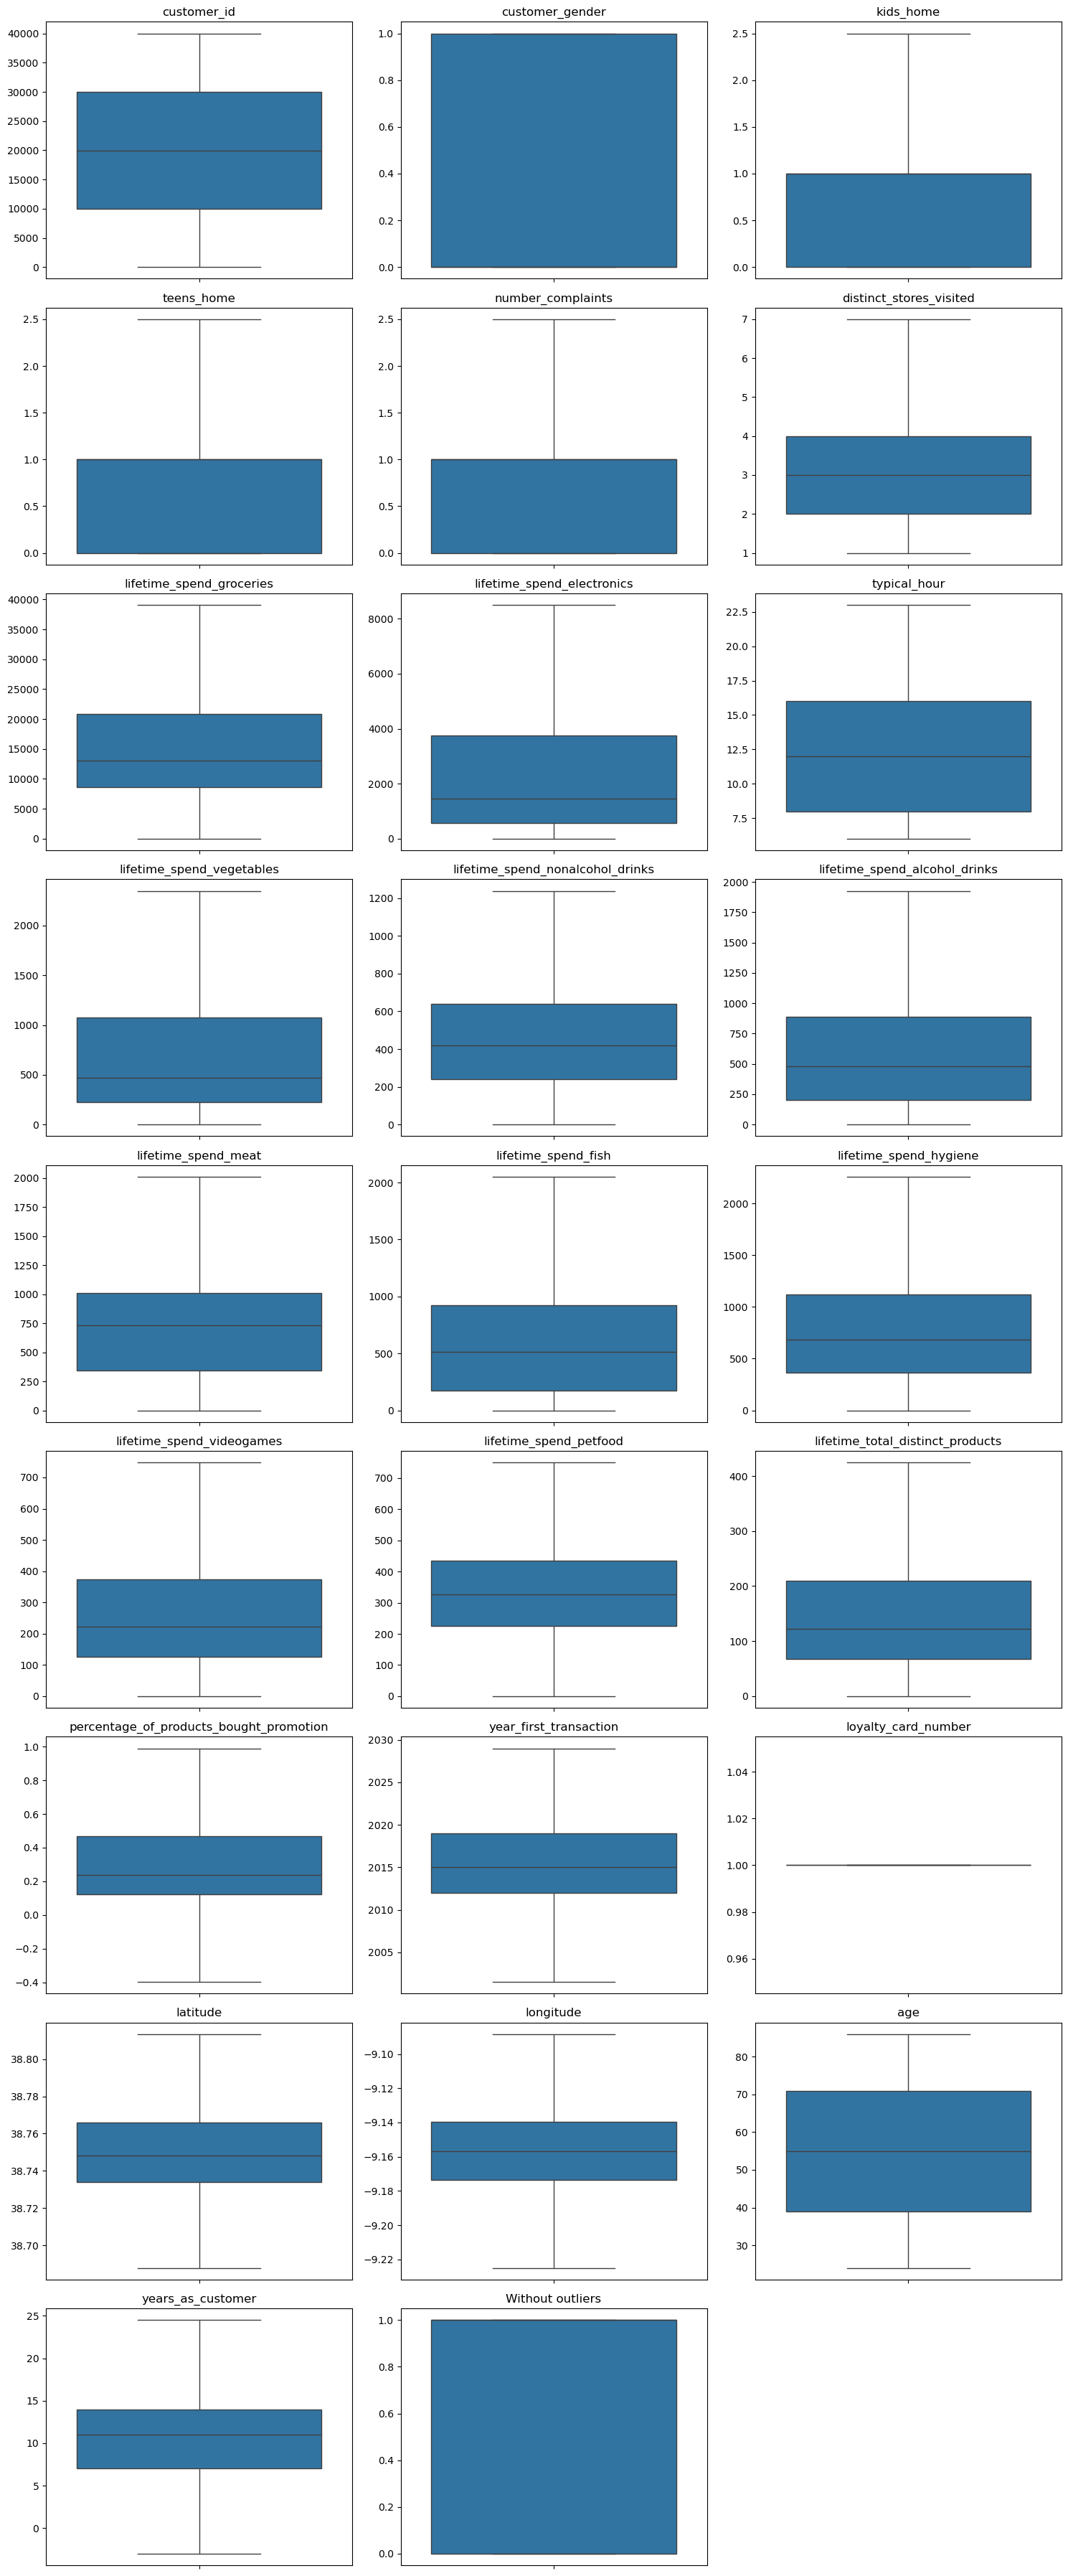

In [11]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.title("Without outliers")
plt.show()

missing values

In [12]:
costumer.isnull().sum()*100/33038

customer_id                                 0.000000
customer_name                               0.000000
customer_gender                             0.000000
customer_birthdate                          0.499425
kids_home                                   0.998850
teens_home                                  0.998850
number_complaints                           2.000726
distinct_stores_visited                     0.998850
lifetime_spend_groceries                    0.000000
lifetime_spend_electronics                  2.000726
typical_hour                                2.000726
lifetime_spend_vegetables                   2.000726
lifetime_spend_nonalcohol_drinks            0.000000
lifetime_spend_alcohol_drinks               0.998850
lifetime_spend_meat                         2.000726
lifetime_spend_fish                         2.999576
lifetime_spend_hygiene                      0.998850
lifetime_spend_videogames                   2.000726
lifetime_spend_petfood                      2.

In [13]:
# Define columns for MICE Imputation
# We drop non-predictive or non-numeric columns that shouldn't influence the imputation
# We also drop latitude/longitude for now to avoid geographic bias in spending imputation
cols_to_drop_for_mice = [
    'customer_id',
    'customer_name',
    'customer_birthdate', 
    'loyalty_card_number', 
    'latitude', 
    'longitude', 
]
cols_mice = costumer.drop(columns=cols_to_drop_for_mice).columns

# 3. Initialize and run the IterativeImputer (MICE)
# Using BayesianRidge as the estimator to maintain statistical relationships
imputer = IterativeImputer(max_iter=10, random_state=42)

# Apply imputation to the selected subset of columns
costumer[cols_mice] = imputer.fit_transform(costumer[cols_mice])

# 4. Final Cleanup
# Removing the original birthdate column as it's no longer needed for clustering
# Removing loyalty_card_number since we replaced it with has_loyalty_card
costumer.drop(columns=['customer_birthdate','loyalty_card_number'], inplace=True)

In [14]:
costumer.isnull().sum()

customer_id                                0
customer_name                              0
customer_gender                            0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                     0
latitude                                   0
longitude 

In [23]:
# 1. Aggregate the basket data (Count how many transactions each customer made)
aggregated_basket = costumer_basket.groupby('customer_id').agg(
    total_transactions=('invoice_id', 'count')
).reset_index()

# 2. Merge your cleaned 'costumer' dataframe with the basket data
combined_df = pd.merge(costumer, aggregated_basket, on='customer_id', how='inner')

# 3. Drop ALL non-predictive columns at once (including the ones you dropped before)
cols_to_drop = ['latitude', 'longitude', 'customer_id', 'customer_name']
existing_cols_to_drop = [col for col in cols_to_drop if col in combined_df.columns]
final_df = combined_df.drop(columns=existing_cols_to_drop)

# 4. Now, initialize the Scaler and scale EVERYTHING (demographics + transactions) together
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df)

# 5. Convert back to DataFrame
costumer_preprocessed = pd.DataFrame(scaled_data, columns=final_df.columns)

# Save the final dataset
costumer_preprocessed.to_csv("costumer_preprocessed_combined.csv", index=False)


costumer data is preprocessed;
lets now see the costumer_basket

In [24]:
costumer_basket = pd.read_csv("customer_basket.csv")
costumer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


In [25]:
costumer_basket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   invoice_id     100000 non-null  int64 
 1   list_of_goods  100000 non-null  object
 2   customer_id    100000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.3+ MB


In [26]:
costumer_basket.duplicated().sum()

np.int64(0)

costumer_basket is okay too

K Means

Mean Shift